# Credit Card Fraud Detection - Logistic Regression

Importing the Dependencies

In [6]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [7]:
# loading the dataset to a Pandas DataFrame
credit_card_data = pd.read_csv('creditcard.csv')

In [8]:
# first 5 rows of the dataset
credit_card_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [9]:
credit_card_data.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [10]:
# dataset informations
credit_card_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [11]:
# checking the number of missing values in each column
credit_card_data.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [12]:
# distribution of legit transactions & fraudulent transactions
credit_card_data['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

This Dataset is highly unblanced

0 --> Normal Transaction

1 --> fraudulent transaction

In [13]:
# separating the data for analysis
legit = credit_card_data[credit_card_data.Class == 0]
fraud = credit_card_data[credit_card_data.Class == 1]

In [14]:
print(legit.shape)
print(fraud.shape)

(284315, 31)
(492, 31)


In [15]:
# statistical measures of the data
legit.Amount.describe()

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

In [16]:
fraud.Amount.describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [17]:
# compare the values for both transactions
credit_card_data.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,...,-0.000644,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


Under-Sampling

Build a sample dataset containing similar distribution of normal transactions and Fraudulent Transactions

Number of Fraudulent Transactions --> 492

In [18]:
legit_sample = legit.sample(n=492)

Concatenating two DataFrames

In [19]:
new_dataset = pd.concat([legit_sample, fraud], axis=0)

In [20]:
new_dataset.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
267183,162659.0,-2.297433,0.472780,-0.654750,-0.017331,0.227946,0.076351,0.148794,0.999374,-0.620660,...,-0.081187,-0.467638,-0.435000,0.174770,0.785601,0.425563,0.176778,-0.299706,159.90,0
251549,155390.0,-0.291233,1.749076,-0.921657,4.362196,0.299671,0.618340,1.338867,0.293834,-2.390760,...,0.301706,0.936688,0.057378,-0.405683,-0.806334,0.461039,0.293763,0.194341,153.25,0
72748,54840.0,-0.530403,0.134243,1.154115,0.190799,0.970940,-0.811166,0.572577,-0.259739,-0.767185,...,0.093540,0.255016,-0.082144,0.068257,-0.320474,0.636448,-0.110997,-0.087970,23.00,0
257112,158008.0,2.066967,-0.058646,-1.288928,0.350483,-0.056166,-1.220739,0.160257,-0.333780,0.706142,...,0.255360,0.894498,0.003666,-0.057593,0.233468,-0.092836,-0.015873,-0.059806,1.00,0
155696,106139.0,-0.590333,1.343584,-2.502931,-1.981110,3.330944,2.724611,0.607574,0.967427,0.754297,...,0.102471,0.582154,-0.120028,0.688854,-0.217111,0.078338,0.371195,0.251383,0.77,0


In [21]:
new_dataset.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
279863,169142.0,-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,...,0.778584,-0.319189,0.639419,-0.294885,0.537503,0.788395,0.292680,0.147968,390.00,1
280143,169347.0,1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,...,0.370612,0.028234,-0.145640,-0.081049,0.521875,0.739467,0.389152,0.186637,0.76,1
280149,169351.0,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,...,0.751826,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361,77.89,1
281144,169966.0,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,...,0.583276,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700,245.00,1
281674,170348.0,1.991976,0.158476,-2.583441,0.408670,1.151147,-0.096695,0.223050,-0.068384,0.577829,...,-0.164350,-0.295135,-0.072173,-0.450261,0.313267,-0.289617,0.002988,-0.015309,42.53,1


In [22]:
new_dataset['Class'].value_counts()

Class
0    492
1    492
Name: count, dtype: int64

In [23]:
new_dataset.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,93654.965447,-0.024870,0.039794,0.112107,-0.023558,0.001649,0.048166,-0.022658,0.036311,-0.012269,...,0.015072,0.000510,-0.026300,-0.023004,-0.029996,0.041134,0.000567,0.003532,0.004922,82.798455
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


Splitting the data into Features & Targets

In [24]:
X = new_dataset.drop(columns='Class', axis=1)
Y = new_dataset['Class']

In [25]:
print(X)

            Time        V1        V2        V3        V4        V5        V6  \
267183  162659.0 -2.297433  0.472780 -0.654750 -0.017331  0.227946  0.076351   
251549  155390.0 -0.291233  1.749076 -0.921657  4.362196  0.299671  0.618340   
72748    54840.0 -0.530403  0.134243  1.154115  0.190799  0.970940 -0.811166   
257112  158008.0  2.066967 -0.058646 -1.288928  0.350483 -0.056166 -1.220739   
155696  106139.0 -0.590333  1.343584 -2.502931 -1.981110  3.330944  2.724611   
...          ...       ...       ...       ...       ...       ...       ...   
279863  169142.0 -1.927883  1.125653 -4.518331  1.749293 -1.566487 -2.010494   
280143  169347.0  1.378559  1.289381 -5.004247  1.411850  0.442581 -1.326536   
280149  169351.0 -0.676143  1.126366 -2.213700  0.468308 -1.120541 -0.003346   
281144  169966.0 -3.113832  0.585864 -5.399730  1.817092 -0.840618 -2.943548   
281674  170348.0  1.991976  0.158476 -2.583441  0.408670  1.151147 -0.096695   

              V7        V8        V9  .

In [26]:
print(Y)

267183    0
251549    0
72748     0
257112    0
155696    0
         ..
279863    1
280143    1
280149    1
281144    1
281674    1
Name: Class, Length: 984, dtype: int64


Split the data into Training data & Testing Data

In [27]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

In [28]:
print(X.shape, X_train.shape, X_test.shape)

(984, 30) (787, 30) (197, 30)


Model Training

Logistic Regression

In [29]:
model = LogisticRegression()

In [30]:
# training the Logistic Regression Model with Training Data
model.fit(X_train, Y_train)

c:\Program Files\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


Model Evaluation

Accuracy Score

In [31]:
# accuracy on training data
X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)

In [32]:
print('Accuracy on Training data : ', training_data_accuracy)

Accuracy on Training data :  0.9491740787801779


In [33]:
# accuracy on test data
X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)

In [34]:
print('Accuracy score on Test Data : ', test_data_accuracy)

Accuracy score on Test Data :  0.934010152284264


✅ Data after undersampling: {0: 492, 1: 492}


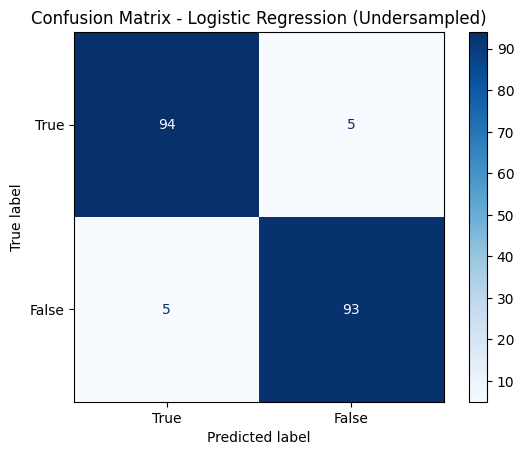

In [ ]:
# ==============================================
# CONFUSION MATRIX - LOGISTIC REGRESSION (UNDERSAMPLED)
# ==============================================

# --- Imports ---
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from imblearn.under_sampling import RandomUnderSampler

# --- Load Dataset ---
df = pd.read_csv('creditcard.csv')

# --- Prepare Data ---
X = df.drop('Class', axis=1)
y = df['Class']

# --- Scale Data ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Undersample Data ---
rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X_scaled, y)
print(f"✅ Data after undersampling: {y_res.value_counts().to_dict()}")

# --- Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)

# --- Train Model ---
model = LogisticRegression(max_iter=1000, n_jobs=-1)
model.fit(X_train, y_train)

# --- Predictions ---
y_pred = model.predict(X_test)

# --- Confusion Matrix ---
conf_matrix = confusion_matrix(y_test, y_pred)
vis = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=[True, False])
vis.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression (Undersampled)')
plt.grid(False)
plt.show()



✅ Data after undersampling: {0: 492, 1: 492}


<Figure size 600x500 with 0 Axes>

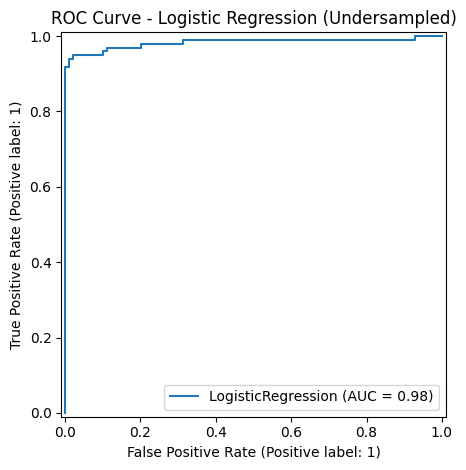

In [38]:
# ==============================================
# ROC CURVE - LOGISTIC REGRESSION (UNDERSAMPLED)
# ==============================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay
from imblearn.under_sampling import RandomUnderSampler

# --- Load Dataset ---
df = pd.read_csv('creditcard.csv')

# --- Prepare Data ---
X = df.drop('Class', axis=1)
y = df['Class']

# --- Scale Data ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Undersample Data ---
rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X_scaled, y)
print(f"✅ Data after undersampling: {y_res.value_counts().to_dict()}")

# --- Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)

# --- Train Model ---
model = LogisticRegression(max_iter=1000, n_jobs=-1)
model.fit(X_train, y_train)

# --- Plot ROC Curve ---
plt.figure(figsize=(6,5))
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title('ROC Curve - Logistic Regression (Undersampled)')
plt.tight_layout()
plt.show()


✅ Data after undersampling: {0: 492, 1: 492}


<Figure size 600x500 with 0 Axes>

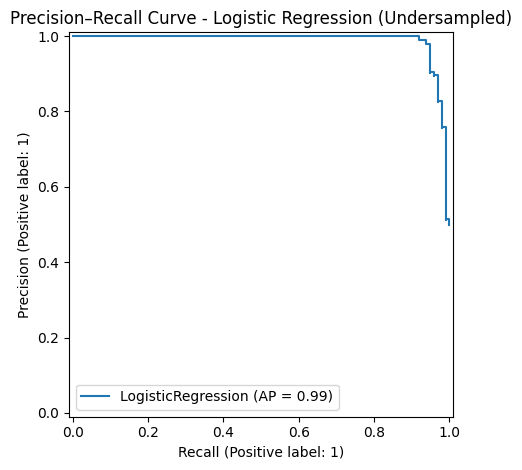

In [39]:
# ==============================================
# PRECISION–RECALL CURVE - LOGISTIC REGRESSION (UNDERSAMPLED)
# ==============================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import PrecisionRecallDisplay
from imblearn.under_sampling import RandomUnderSampler

# --- Load Dataset ---
df = pd.read_csv('creditcard.csv')

# --- Prepare Data ---
X = df.drop('Class', axis=1)
y = df['Class']

# --- Scale Data ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Undersample Data ---
rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X_scaled, y)
print(f"✅ Data after undersampling: {y_res.value_counts().to_dict()}")

# --- Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)

# --- Train Model ---
model = LogisticRegression(max_iter=1000, n_jobs=-1)
model.fit(X_train, y_train)

# --- Plot Precision–Recall Curve ---
plt.figure(figsize=(6,5))
PrecisionRecallDisplay.from_estimator(model, X_test, y_test)
plt.title('Precision–Recall Curve - Logistic Regression (Undersampled)')
plt.tight_layout()
plt.show()
